,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,TypeOfMilkFirstFed1Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
SEQN,,,,,,,,,,,,,,,,,,,,,
93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102952.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,0.0,Never
102953.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,218.0,0.0,Never
102954.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66.0,150.0,0.0,Never


,GeneralHealthCondition,Gender,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays
SEQN,,,,,,,
93703.0,NaN,Female,273.0,1.0,365.0,152.0,365.0
93704.0,NaN,Male,60.0,3.0,365.0,126.0,365.0
93705.0,Good,Female,NaN,NaN,NaN,NaN,NaN
93706.0,Very good,Male,NaN,NaN,NaN,NaN,NaN
93707.0,Good,Male,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
102952.0,Very good,Female,NaN,NaN,NaN,NaN,NaN
102953.0,Fair or,Male,NaN,NaN,NaN,NaN,NaN
102954.0,Good,Female,NaN,NaN,NaN,NaN,NaN


**********************************Missing variable****************************************


39259

,variable,n_missing,n_cases,pct_missing
0,GeneralHealthCondition,2402,8366,28.711451
1,Gender,0,8366,0.000000
2,AgeStoppedBreastfeedingdays,7504,8366,89.696390
3,AgeFirstFedFormuladays,7289,8366,87.126464
4,AgeStoppedReceivingFormuladays,7475,8366,89.349749
5,AgeStartedOtherFoodbeverage,7289,8366,87.126464
6,AgeFirstFedMilkdays,7300,8366,87.257949


,n_missing_in_variable,n_variables,pct_variables
0,7289,2,28.571429
1,0,1,14.285714
2,2402,1,14.285714
3,7300,1,14.285714
4,7475,1,14.285714
5,7504,1,14.285714


None

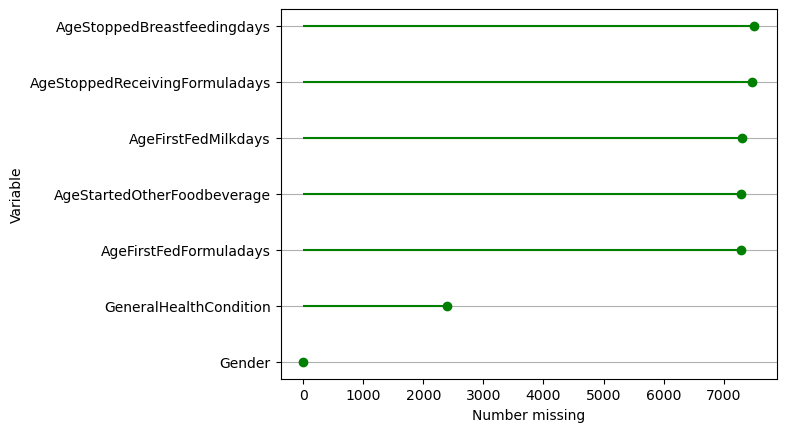

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

#Ejecutamos notebook de pandas missing extensión
%run "D:\\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_5\pandas_missing_extension.ipynb"

import nhanes.load
nhanes_df = nhanes.load.load_NHANES_data(year="2017-2018")
display(nhanes_df)

nhanes_df = nhanes_df[[
        'GeneralHealthCondition',
        'Gender',
        'AgeStoppedBreastfeedingdays', 'AgeFirstFedFormuladays',
       'AgeStoppedReceivingFormuladays', 'AgeStartedOtherFoodbeverage',
       'AgeFirstFedMilkdays']]
display(nhanes_df)

print("**********************************Missing variable****************************************")
display(nhanes_df.missing.number_missing())
display(nhanes_df.missing.missing_variable_summary())
display(nhanes_df.missing.missing_variable_table())
display(nhanes_df.missing.missing_variable_plot())



*****************************Datos faltante********************************************


<Axes: >

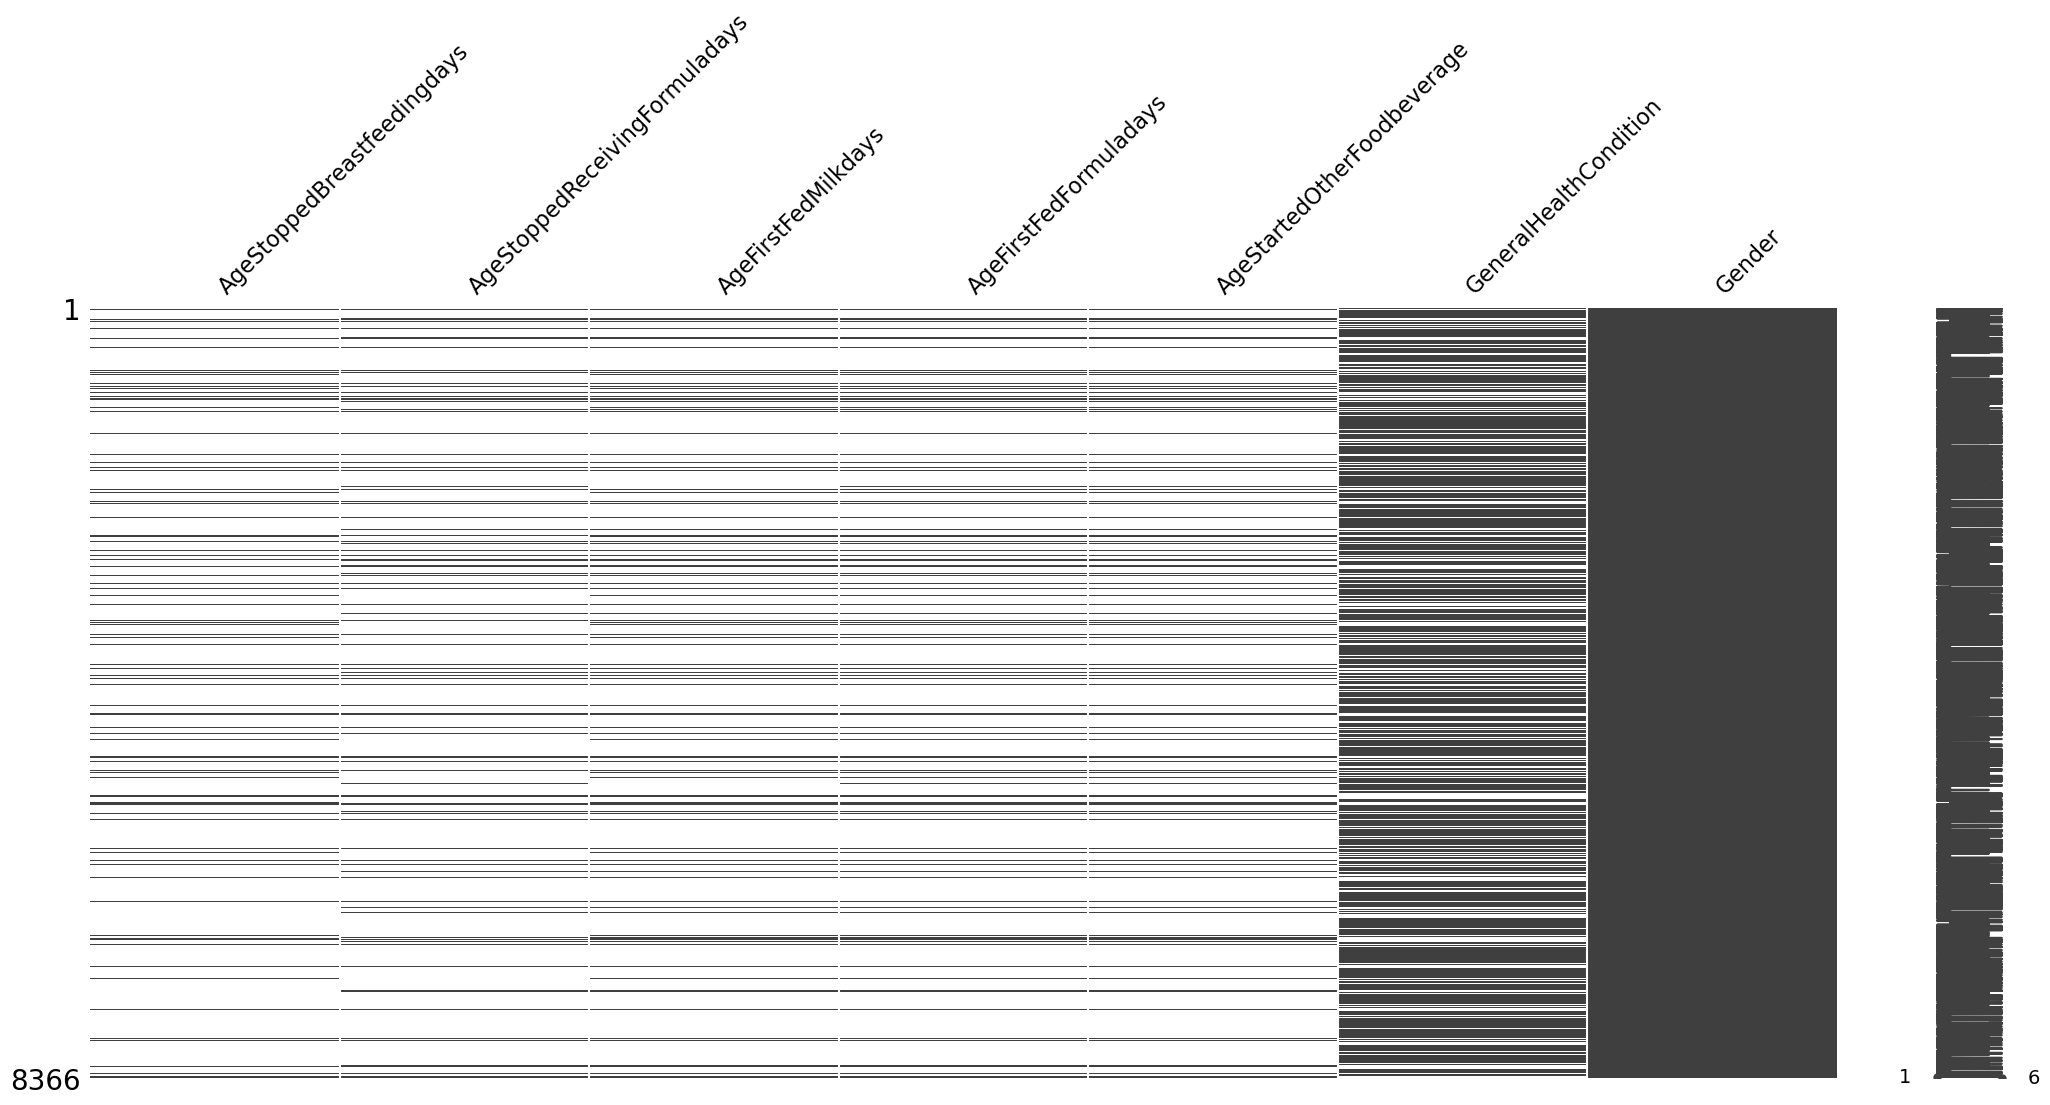

In [3]:
print("*****************************Datos faltante********************************************")
display(
    nhanes_df
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)



*********************IMPUTACIÓN DE AGE STOPPED BREATS FEEDING DAYS**************************


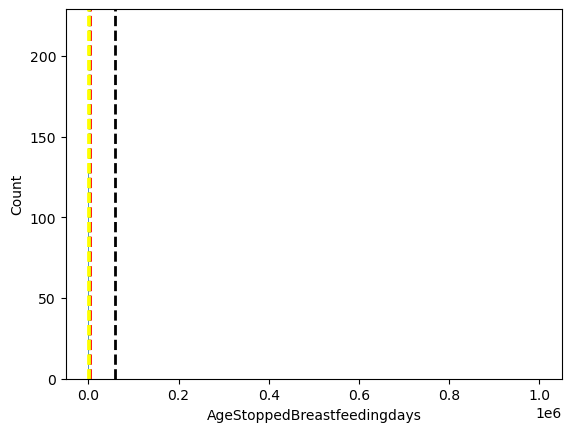

In [4]:
print("*********************IMPUTACIÓN DE AGE STOPPED BREATS FEEDING DAYS**************************")

df = nhanes_df
variable = 'AgeStoppedBreastfeedingdays'
sns.histplot(
    data=df,
    x=variable
)
plt.axvline(
    x=df[variable].mean(),
    color='red',
    linestyle='dashed',
    linewidth=2
)
plt.axvline(
    x=df[variable].median(),
    color='green',
    linestyle='dashed',
    linewidth=2
)
plt.axvline(
    x=df[variable].median() +df[variable].std(),
    color='black',
    linestyle='dashed',
    linewidth=2
)
plt.axvline(
    x=df[variable].quantile(0.25),
    color='yellow',
    linestyle='dashed',
    linewidth=2
)
plt.axvline(
    x=df[variable].quantile(0.75),
    color='yellow',
    linestyle='dashed',
    linewidth=2
)
